# Study 780 — Long-Weekend-Drift — for the quants 🔬

The full battery: one-sample *t* per window, a random-window placebo, a leave-one-out jackknife, an old/recent decay split, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `120ff40dea08`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from long_weekend_drift import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} holidays resolved")


panel loaded; 192 of 192 holidays resolved


## 1. One-sample *t* across independent holiday events

Each holiday is one independent event, so the unit is a one-sample *t* of the per-holiday excess return (over SPY's own mean daily return) — **not** a daily panel (which would fake precision).

In [2]:
mu = st.baseline_daily(prices)
print(f'baseline ordinary-day return = {mu*100:+.4f}%')
for label, col in [('eve pre1','pre1'),('run-up pre3','pre3'),('post1','post1')]:
    s = st.one_sample_t(inc[col].values)
    print(f'{label:<12s} n={s["n"]}  mean={s["mean"]*100:+.4f}%  sd={s["sd"]*100:.3f}%  t={s["t"]:+.3f}')

baseline ordinary-day return = +0.0484%
eve pre1     n=192  mean=+0.0964%  sd=0.872%  t=+1.532
run-up pre3  n=192  mean=+0.2986%  sd=1.885%  t=+2.195
post1        n=192  mean=-0.0314%  sd=1.133%  t=-0.384


## 2. Random-window placebo — is the drift inside the luck cloud?

For each event we redraw a random, non-holiday window on SPY and recompute the excess return; 20 seeds × 200 draws. If the observed mean sits in the tail of that null, it isn't ordinary noise. Note the split verdict: the single-eve is inside the cloud, the 3-session run-up is in the tail.

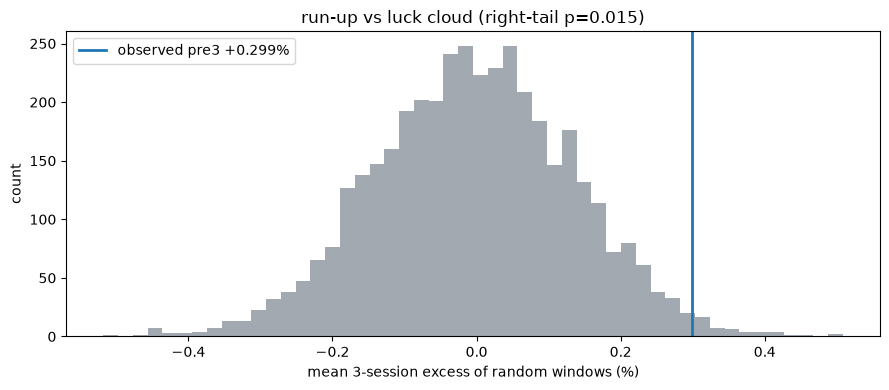

pre1 placebo: {'obs': 0.001, 'placebo_mean': -0.0, 'placebo_sd': 0.0009, 'p_value': 0.1263, 'n_draws': 4000}
pre3 placebo: {'obs': 0.003, 'placebo_mean': -0.0, 'placebo_sd': 0.0014, 'p_value': 0.0145, 'n_draws': 4000}


In [3]:
pl1 = st.placebo_pvalue(ev, prices, 'pre1', k=1, tail='right')
pl3 = st.placebo_pvalue(ev, prices, 'pre3', k=3, tail='right')
spy = prices[dt.INSTRUMENT]; idx = spy.index.sort_values(); mu = st.baseline_daily(prices)
rng = np.random.default_rng(999); draws = []
for _ in range(4000):
    vals = []
    for _e in range(int(inc.shape[0])):
        p = int(rng.integers(3, len(idx)-2))
        vals.append(float(spy.iloc[p]/spy.iloc[p-3]-1.0) - 3*mu)
    draws.append(np.mean(vals))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.8)
ax.axvline(pl3['obs']*100, color='#1f77b4', lw=2, label=f"observed pre3 {pl3['obs']*100:+.3f}%")
ax.set_xlabel('mean 3-session excess of random windows (%)'); ax.set_ylabel('count')
ax.set_title(f"run-up vs luck cloud (right-tail p={pl3['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('pre1 placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl1.items()})
print('pre3 placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl3.items()})

## 3. Jackknife — is the eve drift one holiday, or broad?

In [4]:
x = inc['pre1'].values
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')

full-sample t = +1.532
jackknife t range [+1.273, +1.815] over 192 leave-one-out draws


## 4. Did the anomaly decay? (old vs recent halves)

Published calendar effects usually fade *after* discovery. Here the eve drift is mildly *stronger* in the recent half — but both halves are individually insignificant, so it's persistent weakness, not confirmation.

In [5]:
half = len(inc)//2
for label, sub in [('old 2005->2015', inc.iloc[:half]), ('recent 2015->2025', inc.iloc[half:])]:
    s = st.one_sample_t(sub['pre1'].values)
    print(f'{label:<18s} n={s["n"]:3d}  mean={s["mean"]*100:+.4f}%  t={s["t"]:+.3f}')

old 2005->2015     n= 96  mean=+0.0718%  t=+0.701
recent 2015->2025  n= 96  mean=+0.1210%  t=+1.644


## 5. Tradability — net of costs

Calendar-known entry, so the signal window and the tradable window are the same (gross vs net). The single-day eve trade is **zeroed by a 5 bps round-trip**; the 3-session run-up keeps a positive but marginal net edge that dies by 10 bps.

In [6]:
ev10 = st.build_event_table(prices, cost_bps=10.0); inc10 = ev10[ev10['included']]
for base, label in [('pre1','eve'),('pre3','3-sess run-up')]:
    g = st.one_sample_t(inc[base].values); n5 = st.one_sample_t(inc[base+'_net'].values); n10 = st.one_sample_t(inc10[base+'_net'].values)
    print(f'{label:<14s} gross {g["mean"]*100:+.4f}% (t={g["t"]:+.2f})  net@5 {n5["mean"]*100:+.4f}% (t={n5["t"]:+.2f})  net@10 {n10["mean"]*100:+.4f}% (t={n10["t"]:+.2f})')

eve            gross +0.0964% (t=+1.53)  net@5 -0.0036% (t=-0.06)  net@10 -0.1036% (t=-1.65)


3-sess run-up  gross +0.2986% (t=+2.20)  net@5 +0.1986% (t=+1.46)  net@10 +0.0986% (t=+0.72)


## 6. Synthetic positive control — the detector works, and the null is clean

The one-sample-*t* detector must stay quiet on a planted-null world and recover a planted pre-holiday bump. At n ≈ 190 the null is well-behaved (~5% FPR), so the observed *t* = 1.53 really is unremarkable — and a real 0.4% bump would land at *t* ≈ 4.

null: mean t=+0.06 sd=1.05  |t|>=2 in 2/20 seeds
planted +0.2%: mean excess +0.1610%  t=+1.97
planted +0.4%: mean excess +0.3537%  t=+4.34


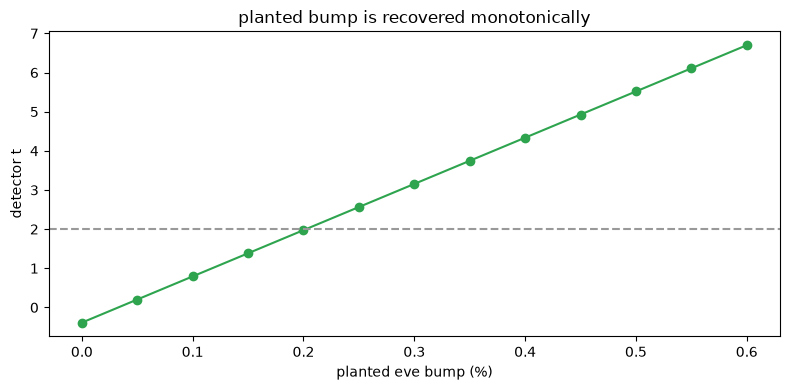

In [7]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=792+s, k=1)['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for b in (0.002, 0.004):
    r = st.synthetic_detect(bump=b, seed=792, k=1)
    print(f'planted +{b*100:.1f}%: mean excess {r["mean"]*100:+.4f}%  t={r["t"]:+.2f}')
bumps = np.linspace(0, 0.006, 13)
ts = [st.synthetic_detect(bump=b, seed=792, k=1)['t'] for b in bumps]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(bumps*100, ts, 'o-', color='#2ea44f')
ax.axhline(2, color='0.6', ls='--'); ax.set_xlabel('planted eve bump (%)'); ax.set_ylabel('detector t')
ax.set_title('planted bump is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: Weak.** The drift is directionally real and jackknife-stable (eve +0.10%, hit 58%; 3-session run-up +0.30%, *t* = +2.20, placebo p = 0.014) — but the classic single-eve cut is insignificant (*t* = +1.53, p = 0.13), significance only appears on the wider window, and the detector is well-powered at n = 190. **Tradability: Fragile.** Survives gross on the run-up with ample SPY capacity, but the single-day version is zeroed by a 5 bps round-trip and the run-up's net edge is marginal and gone by 10 bps — a break-even, cost-sensitive echo, not a bankable edge.